In [1]:
#### for Ming Chen: mesh_boundary_plot.py

In [8]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import math
import uxarray as ux

In [9]:
def boundary_vertices(lonVertex, latVertex, bdyMaskVertex, edgesOnVertex, verticesOnEdge, bdyMask):
    bdyLats = []
    bdyLons = []

    for startVertex in range(bdyMaskVertex.size):
        if bdyMaskVertex[startVertex] == bdyMask:
            break

    for edge in edgesOnVertex[startVertex][:]:
        if edge == -1:
            continue

        if verticesOnEdge[edge][0] != startVertex:
            neighbor = verticesOnEdge[edge][0]
        else:
            neighbor = verticesOnEdge[edge][1]

        if bdyMaskVertex[neighbor] == bdyMask:
            nextVertex = neighbor
            bdyLons.append(lonVertex[nextVertex])
            bdyLats.append(latVertex[nextVertex])
            break

    prevVertex = startVertex

    while nextVertex != startVertex:
        for edge in edgesOnVertex[nextVertex][:]:
            if edge == -1:
                continue

            if verticesOnEdge[edge][0] != nextVertex:
                neighbor = verticesOnEdge[edge][0]
            else:
                neighbor = verticesOnEdge[edge][1]

            if bdyMaskVertex[neighbor] == bdyMask and neighbor != prevVertex:
                prevVertex = nextVertex
                nextVertex = neighbor
                bdyLons.append(lonVertex[nextVertex])
                bdyLats.append(latVertex[nextVertex])
                break

    return np.asarray(bdyLons), np.asarray(bdyLats)

In [10]:
def mesh_extent(latField, lonField):
    earthRadius = 6371229.0
    extentLat = (max(latField) - min(latField)) * earthRadius * math.pi / 180.0
    extentLon = (max(lonField) - min(lonField)) * math.cos(cenLat * math.pi / 180.0) * earthRadius * math.pi / 180.0
    return max(extentLat, extentLon)


In [17]:
def map_background(cenLat, cenLon, extent):
    import cartopy.feature as cfeature
    import matplotlib.ticker as mticker

    proj = ccrs.Stereographic(cenLat, cenLon)
    ax = plt.axes(projection=proj)

    #### MGD
    # print(proj.transform_point(-110.0, 40.0, ccrs.PlateCarree()))

    ax.set_title('Limited-area mesh')

    scaling = 1.5
    ax.set_extent([-scaling * extent, scaling * extent, -scaling * extent, scaling * extent], crs=proj)

    ax.add_feature(cfeature.LAND)
    ax.add_feature(cfeature.OCEAN)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.1)
    ax.add_feature(cfeature.BORDERS, linewidth=0.1)
    ax.add_feature(cfeature.LAKES, linewidth=0.1)
    ax.add_feature(cfeature.RIVERS, linewidth=0.1)
    ax.add_feature(cfeature.STATES, linewidth=0.1)

    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=False,
		      linewidth=0.1, color='black', alpha=1.0, linestyle='--')

#mchen    xticks = np.arange(-180, 180, 15)
#mchen    yticks = np.arange(-90, 90, 15)
    xticks = np.arange(-30, 30, 15)
    yticks = np.arange(30, 70, 15)

    gl.ylocator = mticker.FixedLocator(yticks)
    gl.xlocator = mticker.FixedLocator(xticks)

    return proj, ax


In [18]:
def draw_domain(ax, bdyLats, bdyLons, bdyLatsSpec, bdyLonsSpec):
    import matplotlib.patches as mpatches

    poly_corners = np.zeros((len(bdyLons), 2), np.float64)
    poly_corners[:,0] = np.asarray(bdyLons)
    poly_corners[:,1] = np.asarray(bdyLats)

    poly = mpatches.Polygon(poly_corners, closed=True, ec='black', fill=True, lw=0.1, fc='black', alpha=0.3, transform=ccrs.Geodetic())
    ax.add_patch(poly)

    poly_corners = np.zeros((len(bdyLonsSpec), 2), np.float64)
    poly_corners[:,0] = np.asarray(bdyLonsSpec)
    poly_corners[:,1] = np.asarray(bdyLatsSpec)

    poly = mpatches.Polygon(poly_corners, closed=True, ec='black', fill=True, lw=0.1, fc='black', alpha=0.3, transform=ccrs.Geodetic())
    ax.add_patch(poly)



In [ ]:
# Ming Ge:

import cartopy.feature as cfeature
# Create a Lambert Conformal map projection
projection = ccrs.LambertConformal(central_longitude=cenLon, central_latitude=cenLat)

# Set up the figure and axis
fig, ax = plt.subplots(figsize=(10, 8),
                       subplot_kw={'projection': projection})

# Set extent: [west_lon, east_lon, south_lat, north_lat]
ax.set_extent([ lonVertex.min(), lonVertex.max(), latVertex.min(), latVertex.max()], crs=ccrs.PlateCarree())

# Add features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES, edgecolor='gray')
ax.gridlines(draw_labels=True)

plt.title('Lambert Conformal Projection Map')
plt.show()

6769515.023973753


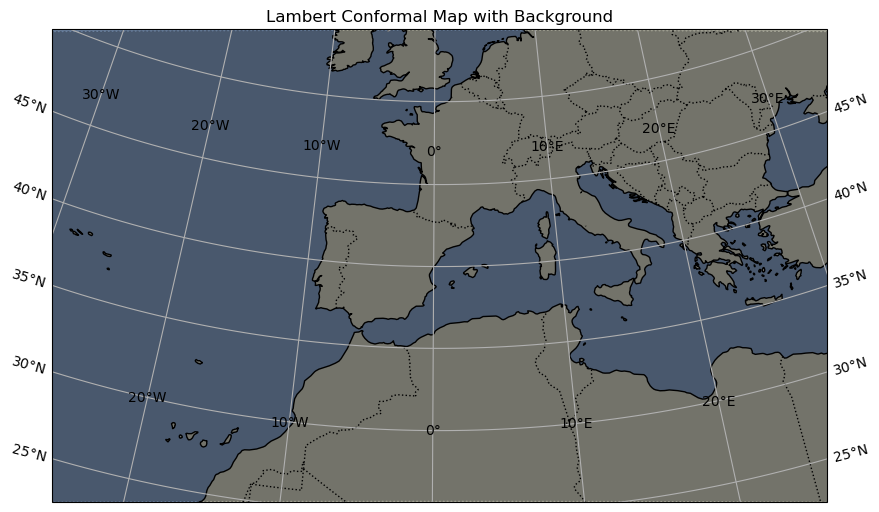

In [19]:
if __name__ == '__main__':
    from time import time
    from netCDF4 import Dataset

    
    f = Dataset('/Users/mingge/MPAS_PROJ/mpas_hex_mesh.nc')

    latVertex = np.ma.getdata(f.variables['latVertex'][:]) * 180.0 / math.pi
    lonVertex = np.ma.getdata(f.variables['lonVertex'][:]) * 180.0 / math.pi
    lonVertex = np.where(lonVertex <= 180,lonVertex, lonVertex-360)
    bdyMaskVertex = np.ma.getdata(f.variables['bdyMaskVertex'][:])
    edgesOnVertex = np.ma.getdata(f.variables['edgesOnVertex'][:]) - 1
    verticesOnEdge = np.ma.getdata(f.variables['verticesOnEdge'][:]) - 1

    f.close()
     
    # calculate domain extents 
    cenLat = np.sum(latVertex) / latVertex.size
    cenLon = np.sum(lonVertex) / lonVertex.size
    extent = mesh_extent(latVertex, lonVertex)
    print(extent)

    # set up map background:
    #proj, ax = map_background(cenLat, cenLon, extent)
    # Step 1: Choose your projection
    proj = ccrs.LambertConformal(central_longitude=cenLon, central_latitude=cenLat)

    # Step 2: Create the figure and axis with projection
    fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': proj})

    # Step 3: Set extent (longitude and latitude bounds)
    # Set extent: [west_lon, east_lon, south_lat, north_lat]
    ax.set_extent([ lonVertex.min()+13, lonVertex.max()-13, latVertex.min()+4, latVertex.max()-3], crs=ccrs.PlateCarree())


    # Step 4: Add background features
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.STATES.with_scale('50m'), edgecolor='gray')
    ax.add_feature(cfeature.LAND)
    ax.add_feature(cfeature.OCEAN)
    ax.gridlines(draw_labels=True)

    # Optional: Add a title
    ax.set_title("Lambert Conformal Map with Background")

    # Step 5: Show the plot
    #plt.show()
      
    bdyLons, bdyLats = boundary_vertices(lonVertex, latVertex, bdyMaskVertex, edgesOnVertex, verticesOnEdge, 1)
    bdyLonsSpec, bdyLatsSpec = boundary_vertices(lonVertex, latVertex, bdyMaskVertex, edgesOnVertex, verticesOnEdge, 7)
    
    draw_domain(ax, bdyLats, bdyLons, bdyLatsSpec, bdyLonsSpec)
   
    #plt.savefig('mesh.pdf')
    

#### Uxarray

In [20]:
grid_file =  '/Users/mingge/MPAS_PROJ/mpas_hex_mesh.nc'
uxgrid = ux.open_grid(grid_file, use_dual=False)


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W

:Path   [Longitude,Latitude]
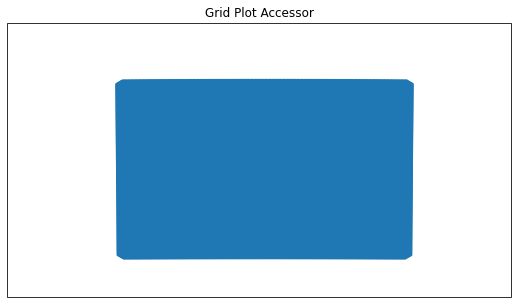

In [21]:
uxgrid.plot(
    height=500,
    width=750,
    title="Grid Plot Accessor",
    backend="matplotlib",
    projection=proj
)

:Overlay
   .Path.I      :Path   [Longitude,Latitude]
   .Coastline.I :Feature   [Longitude,Latitude]
   .Borders.I   :Feature   [Longitude,Latitude]
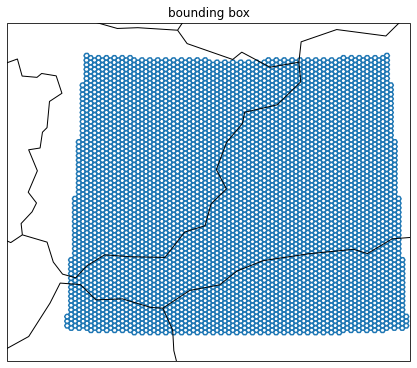

In [23]:
cenlat  = cenLat 
cenlon  = cenLon
 
 
lon_bounds = (cenlon - 6, cenlon + 6)
lat_bounds = (cenlat - 4, cenlat + 4)

bbox_subset = uxgrid.subset.bounding_box(lon_bounds = lon_bounds, lat_bounds=lat_bounds)
bbox_subset.plot.edges(backend='matplotlib', 
                       height=400, width=600,
                       title="bounding box",
                       projection=proj , 
                       features=["borders", "coastline"])  


:Overlay
   .Path.I      :Path   [Longitude,Latitude]
   .Coastline.I :Feature   [Longitude,Latitude]
   .Borders.I   :Feature   [Longitude,Latitude]
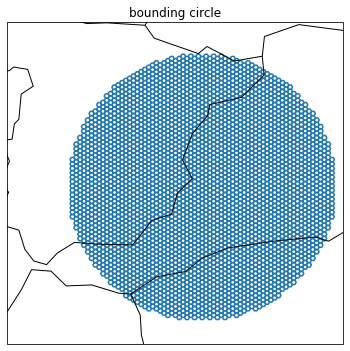

In [24]:
center_coord = [cenlon, cenlat ]
r = 4

bcircle_subset = uxgrid.subset.bounding_circle(center_coord, r)
bcircle_subset.plot.edges(backend='matplotlib', 
                                  height=500, width=500,
                       title="bounding circle",
                       projection=proj , 
                       features=["borders", "coastline"])
